In [2]:
# Import the compact ExperimentRunner and required libs
import os
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from quantum_logical.experiment_runner import ExperimentRunner


runner = ExperimentRunner()

In [3]:
def ideal_plot_results(trotter_dt: float, state_list_4: List[qt.Qobj], state_list_5: List[qt.Qobj], no_correction:list[qt.Qobj], output_path: str, t1, t2) -> None:
    """Create and save diagnostic plots for a completed experiment.

    The function computes time-steps from `trotter_dt` and extracts marginal
    probabilities and fidelities from `state_list`. It writes three PNG files
    (`probabilities_plot.png`, `fidelities_plot.png`, `ancillary_probabilities_plot.png`) into
    `output_path` and also displays them via `matplotlib`.

    Args:
        trotter_dt: Time resolution used during simulation (used to label x-axis).
        state_list: Ordered list of `qutip.Qobj` states from the simulation.
        output_path: Directory where PNGs will be written (created if missing).

    Returns:
        None
    """
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    time_steps_4 = np.linspace(0, trotter_dt * (len(state_list_4)), len(state_list_4))
    time_steps_5 = np.linspace(0, trotter_dt * (len(state_list_5)), len(state_list_5))

    probabilities_4 = [state.ptrace([0, 1, 2]).diag().real for state in state_list_4]
    probabilities_4 = np.array(probabilities_4)

    probabilities_5 = [state.ptrace([0, 1, 2]).diag().real for state in state_list_5]
    probabilities_5 = np.array(probabilities_5)

    plus_state = qt.gates.snot() * qt.basis(2, 0)
    init_state = qt.tensor(plus_state, plus_state, plus_state)
    init_rho = qt.ket2dm(init_state)

    fidelities_4 = [qt.fidelity(state.ptrace([0, 1, 2]), init_rho) for state in state_list_4]
    fidelities_4 = np.array(fidelities_4)

    fidelities_5 = [qt.fidelity(state.ptrace([0, 1, 2]), init_rho) for state in state_list_5]
    fidelities_5 = np.array(fidelities_5)

    fidelity_no_correction = [qt.fidelity(state.ptrace([0, 1, 2]), init_rho) for state in no_correction]
    fidelity_no_correction = np.array(fidelity_no_correction)

    plt.figure(figsize=(10, 6))
    plt.plot(time_steps_4, fidelities_4, label="4Q Fidelity")
    plt.plot(time_steps_5, fidelities_5, label="5Q Fidelity")
    plt.plot(time_steps_4, fidelity_no_correction, label="No Correction Fidelity")
    plt.xlabel(r"Time Step ($\mu$s)")
    plt.ylabel("Fidelities")
    plt.suptitle(f"Fidelity between |+++> Over Time with T1 = {t1:.1f}μs, T2 = {t2:.1f}μs")
    plt.title(f"Final Fidelity: 4Q: {fidelities_4[-1]:.4f}, 5Q: {fidelities_5[-1]:.4f}")
    plt.legend()
    plt.savefig(f"{output_path}/fidelities_plot.png")
    plt.show()

In [4]:
def ideal_plot_results_log_plot(trotter_dt, state_list_4, state_list_5, no_correction,
                                  output_path, t1, t2):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    time_steps_4 = np.linspace(0, trotter_dt * len(state_list_4), len(state_list_4))
    time_steps_5 = np.linspace(0, trotter_dt * len(state_list_5), len(state_list_5))
    time_steps_nc = np.linspace(0, trotter_dt * len(no_correction), len(no_correction))

    plus_state = qt.gates.snot() * qt.basis(2, 0)
    init_rho = qt.ket2dm(qt.tensor(plus_state, plus_state, plus_state))

    # qt.fidelity returns sqrt-fidelity; square it to get the standard Uhlmann F
    def infid(states):
        F = np.array([qt.fidelity(s.ptrace([0, 1, 2]), init_rho) for s in states]) ** 2
        return 1 - F

    infid_4  = infid(state_list_4)
    infid_5  = infid(state_list_5)
    infid_nc = infid(no_correction)

    # Guard against exactly-1 fidelity producing zero infidelity
    floor = 1e-12
    infid_4  = np.clip(infid_4,  floor, None)
    infid_5  = np.clip(infid_5,  floor, None)
    infid_nc = np.clip(infid_nc, floor, None)

    from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(time_steps_4,  infid_4, label='4-qubit (sequential)')
    ax.plot(time_steps_5,  infid_5, label='5-qubit (parallel)')
    ax.plot(time_steps_nc, infid_nc, label='no correction')

    ax.set_yscale('log')

    nines = range(1, 5)
    tick_positions = [10.0 ** (-k) for k in nines]
    tick_labels = ['0.' + '9' * k for k in nines]

    ax.set_ylim(10 ** (-(max(nines) + 0.3)), 10 ** (-(min(nines) - .9)))
    ax.yaxis.set_major_locator(FixedLocator(tick_positions))
    ax.yaxis.set_major_formatter(FixedFormatter(tick_labels))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.invert_yaxis()
    ax.set_ylabel('Fidelity')
    ax.set_xlabel('Time (μs)')
    ax.legend()
    ax.grid(True, which='major', alpha=0.3)

    ax.set_title(f"Fidelity between |+++> Over Time with T1 = {t1:.1f}μs, T2 = {t2:.1f}μs")
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'fidelities_plot.png'), dpi=150)
    plt.show()

In [5]:
from quantum_logical.qubit_phase import qubit_parallel_phase_circuit, qubit_partial_phase_circuit


single_qubit_time = 0.03 # 30 nanosec
two_qubit_time = 0.102 # 102 nanosec

plus_state = qt.gates.snot() * qt.basis(2,0)
init_state = qt.tensor(plus_state, plus_state, plus_state)

init_rho = qt.ket2dm(init_state)

T1 = 280 # microseconds
T2 = 330 # microseconds

trotterer_4 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 4)
trotterer_5 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 5)

setup_5 = [
    qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2),
    qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2),
    qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2),
    
]

setup_4 = [
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),

    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),

    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
]

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotterer_4, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotterer_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)


ideal_dropped_states_4 = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
    
ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37], [37 * single_qubit_time])[1:-1]
ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19], [19 * single_qubit_time])[1:-1]
ideal_dropped_states_4.append(state_list_4[37*2])
ideal_dropped_states_5.append(state_list_5[19*2])
    
ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 *2], [37 * single_qubit_time])[1:-1]
ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 *2], [19 * single_qubit_time])[1:-1]
ideal_dropped_states_4.append(state_list_4[37*3])
ideal_dropped_states_5.append(state_list_5[19*3])
    


[<quantum_logical.channel.AmplitudeDamping object at 0x7f8bcfdf57d0>, <quantum_logical.channel.PhaseDamping object at 0x7f8bcfe28350>]
[<quantum_logical.channel.AmplitudeDamping object at 0x7f8bcdba5dd0>, <quantum_logical.channel.PhaseDamping object at 0x7f8bcdba5d10>]


In [6]:
from quantum_logical.qubit_phase import qubit_parallel_phase_circuit, qubit_partial_phase_circuit


single_qubit_time = 0.03 # 30 nanosec
two_qubit_time = 0.102 # 102 nanosec

plus_state = qt.gates.snot() * qt.basis(2,0)
init_state = qt.tensor(plus_state, plus_state, plus_state)

init_rho = qt.ket2dm(init_state)

T1 = 280 # microseconds
T2 = 330 # microseconds

trotterer_4 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 4)
trotterer_5 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 5)

setup_5 = [
    qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2),
    qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2),
    qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2),
    
]

setup_4 = [
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),

    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),

    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
    qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
]

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotterer_4, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotterer_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)


ideal_dropped_states_4 = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
    
ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37], [37 * single_qubit_time])[1:-1]
ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19], [19 * single_qubit_time])[1:-1]
ideal_dropped_states_4.append(state_list_4[37*2])
ideal_dropped_states_5.append(state_list_5[19*2])
    
ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 *2], [37 * single_qubit_time])[1:-1]
ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 *2], [19 * single_qubit_time])[1:-1]
ideal_dropped_states_4.append(state_list_4[37*3])
ideal_dropped_states_5.append(state_list_5[19*3])
    


[<quantum_logical.channel.AmplitudeDamping object at 0x7f8bfb35bb50>, <quantum_logical.channel.PhaseDamping object at 0x7f8bcdb92090>]
[<quantum_logical.channel.AmplitudeDamping object at 0x7f8bcddc7450>, <quantum_logical.channel.PhaseDamping object at 0x7f8bcfdf4590>]


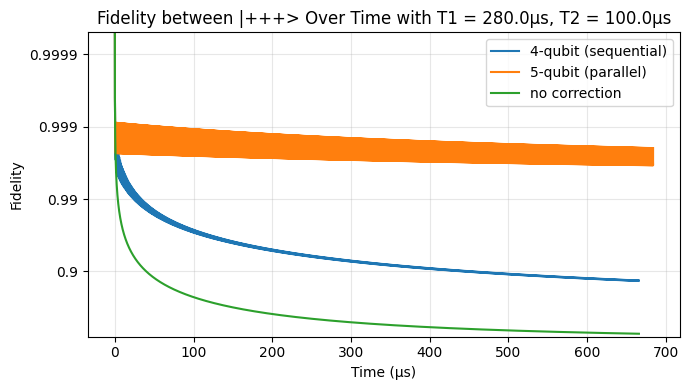

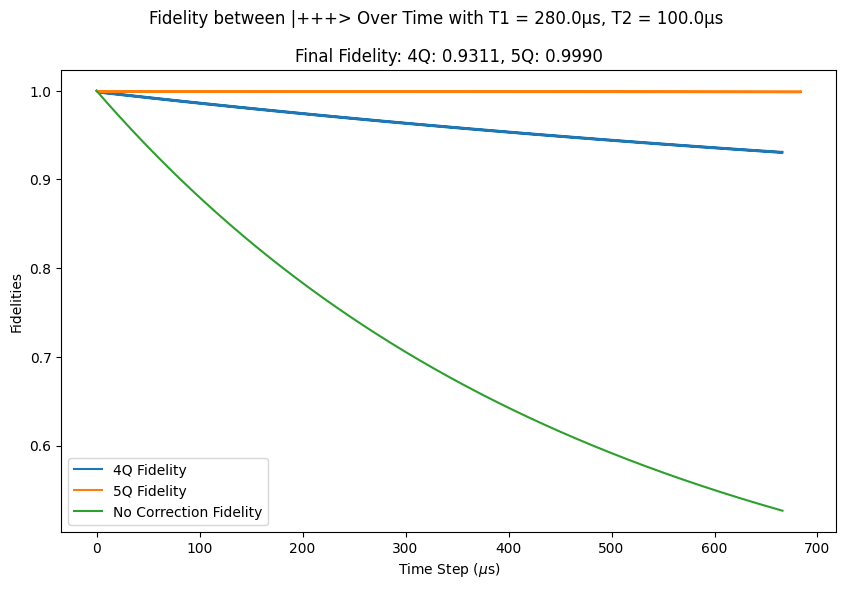

In [12]:
from quantum_logical.channel import AmplitudeDamping
from quantum_logical.trotter import TrotterGroup


T1= 280
T2= 100
n = 600

setup_5 = [
qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2)
] * 2*n

setup_4 = [
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
] * n

trotter_decoherence = TrotterGroup([AmplitudeDamping(280, num_qubits=4, hilbert_space_dim=2)], .03)
trotter_decoherence_5 = TrotterGroup([AmplitudeDamping(280, num_qubits=5, hilbert_space_dim=2)], .03)

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotter_decoherence, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotter_decoherence_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)

ideal_dropped_states_4 = [qt.tensor(init_rho, ancilla_zero)]
ideal_dropped_states_5 = [qt.tensor(init_rho, ancilla_zero, ancilla_zero)]
ideal_dropped_states_4 = runner.run_unitary_circuit(trotter_decoherence, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotter_decoherence_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
for i in range(1,n):
    ideal_dropped_states_4 += runner.run_unitary_circuit(trotter_decoherence, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 * i], [37 * single_qubit_time])[1:-1]
    ideal_dropped_states_4.append(state_list_4[37*(i+1)])
for i in range(1,2*n):
    ideal_dropped_states_5 += runner.run_unitary_circuit(trotter_decoherence_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 * i], [19 * single_qubit_time])[1:-1]
    ideal_dropped_states_5.append(state_list_5[19*(i+1)])
    
no_correction = runner.run_unitary_circuit(trotter_decoherence, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   

ideal_plot_results_log_plot(0.03, ideal_dropped_states_4, ideal_dropped_states_5, no_correction, f"results/T1_{T1}_T2_{T2}/ideals", T1, T2)

ideal_plot_results(0.03, ideal_dropped_states_4, ideal_dropped_states_5, no_correction, "helpme", T1, T2)
    

[<quantum_logical.channel.AmplitudeDamping object at 0x7f8bcdb92150>, <quantum_logical.channel.PhaseDamping object at 0x7f8bcdb92450>]
[<quantum_logical.channel.AmplitudeDamping object at 0x7f8bfb35bb50>, <quantum_logical.channel.PhaseDamping object at 0x7f8bcdb93c50>]


/home/wrn13/Research/QuantumLogicalSimulator/.venv/lib/python3.11/site-packages/qutip/core/data/expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


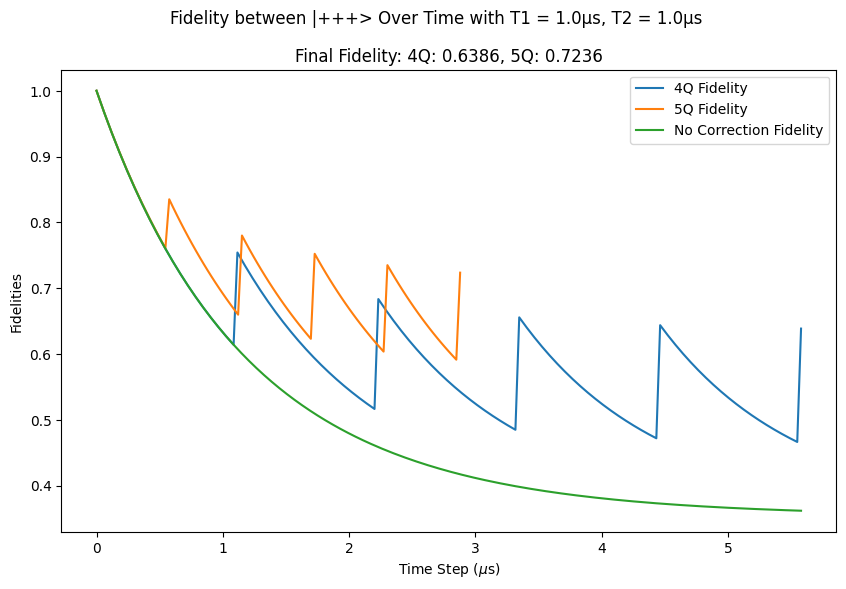

In [ ]:
T1 = 1
T2 = 1
trotterer_4 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 4)
trotterer_5 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 5)
n = 5

setup_5 = [
qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2)
] * n

setup_4 = [
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
] * n

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotterer_4, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotterer_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)

ideal_dropped_states_4 = [qt.tensor(init_rho, ancilla_zero)]
ideal_dropped_states_5 = [qt.tensor(init_rho, ancilla_zero, ancilla_zero)]
ideal_dropped_states_4 = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
for i in range(1,n):
    ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 * i], [37 * single_qubit_time])[1:-1]
    ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 * i], [19 * single_qubit_time])[1:-1]
    ideal_dropped_states_4.append(state_list_4[37*(i+1)])
    ideal_dropped_states_5.append(state_list_5[19*(i+1)])
    
no_correction = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   

ideal_plot_results(single_qubit_time, ideal_dropped_states_4, ideal_dropped_states_5, no_correction, "results/ideal_plots", T1, T2)

/home/wrn13/Research/QuantumLogicalSimulator/.venv/lib/python3.11/site-packages/qutip/core/data/expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
/home/wrn13/Research/QuantumLogicalSimulator/.venv/lib/python3.11/site-packages/qutip/core/data/expm.py:139: LinAlgWarning: Matrix is ill-conditioned. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


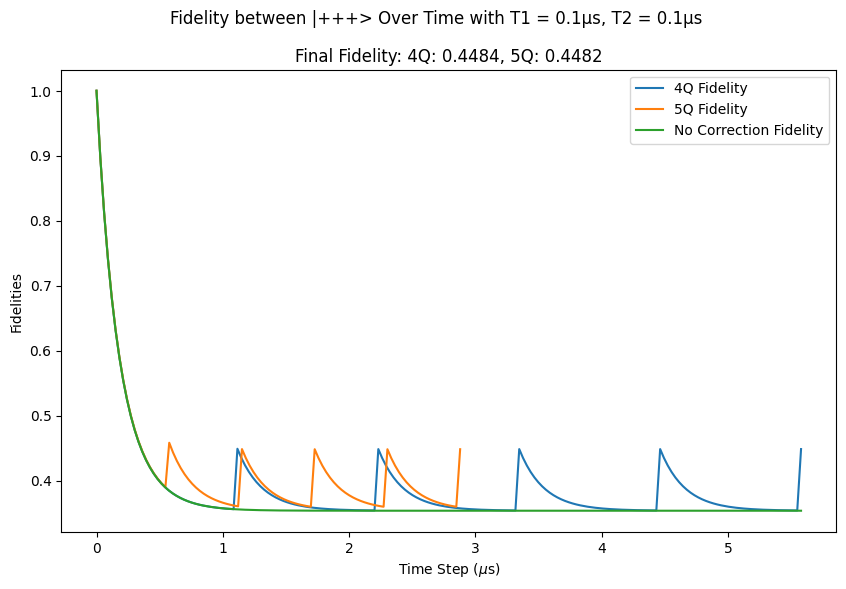

In [12]:
from quantum_logical.trotter import TrotterGroup
from quantum_logical.channel import AmplitudeDamping

T1 = .1
T2 = .1
trotterer_4 = TrotterGroup([AmplitudeDamping(T1, 4, 2)], 0.03)
trotterer_5 = TrotterGroup([AmplitudeDamping(T1, 5, 2)], 0.03)
n = 5

setup_5 = [
qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2)
] * n

setup_4 = [
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
] * n

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotterer_4, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotterer_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)

ideal_dropped_states_4 = [qt.tensor(init_rho, ancilla_zero)]
ideal_dropped_states_5 = [qt.tensor(init_rho, ancilla_zero, ancilla_zero)]
ideal_dropped_states_4 = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
for i in range(1,n):
    ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 * i], [37 * single_qubit_time])[1:-1]
    ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 * i], [19 * single_qubit_time])[1:-1]
    ideal_dropped_states_4.append(state_list_4[37*(i+1)])
    ideal_dropped_states_5.append(state_list_5[19*(i+1)])
    
no_correction = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   

ideal_plot_results(single_qubit_time, ideal_dropped_states_4, ideal_dropped_states_5, no_correction, "results/ideal_plots", T1, T2)

[<quantum_logical.channel.AmplitudeDamping object at 0x7f970c6458d0>, <quantum_logical.channel.PhaseDamping object at 0x7f9712d91710>]
[<quantum_logical.channel.AmplitudeDamping object at 0x7f970c8fd650>, <quantum_logical.channel.PhaseDamping object at 0x7f970c6e8090>]


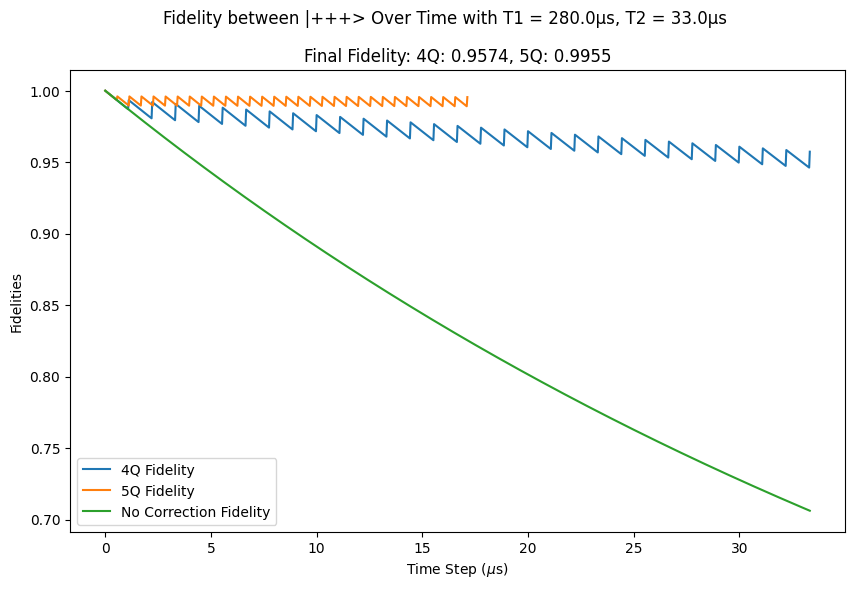

In [ ]:
T1 = 280
T2 = 330
trotterer_4 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 4)
trotterer_5 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 5)
n = 30

setup_5 = [
qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2)
] * n

setup_4 = [
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
] * n

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotterer_4, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotterer_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)

ideal_dropped_states_4 = [qt.tensor(init_rho, ancilla_zero)]
ideal_dropped_states_5 = [qt.tensor(init_rho, ancilla_zero, ancilla_zero)]
ideal_dropped_states_4 = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
for i in range(1,n):
    ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 * i], [37 * single_qubit_time])[1:-1]
    ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 * i], [19 * single_qubit_time])[1:-1]
    ideal_dropped_states_4.append(state_list_4[37*(i+1)])
    ideal_dropped_states_5.append(state_list_5[19*(i+1)])
    
no_correction = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   

ideal_plot_results(single_qubit_time, ideal_dropped_states_4, ideal_dropped_states_5, no_correction, "results/ideal_plots", T1, T2)

[<quantum_logical.channel.AmplitudeDamping object at 0x7f970d983d10>, <quantum_logical.channel.PhaseDamping object at 0x7f970caba290>]


/home/wrn13/Research/QuantumLogicalSimulator/.venv/lib/python3.11/site-packages/qutip/core/data/expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


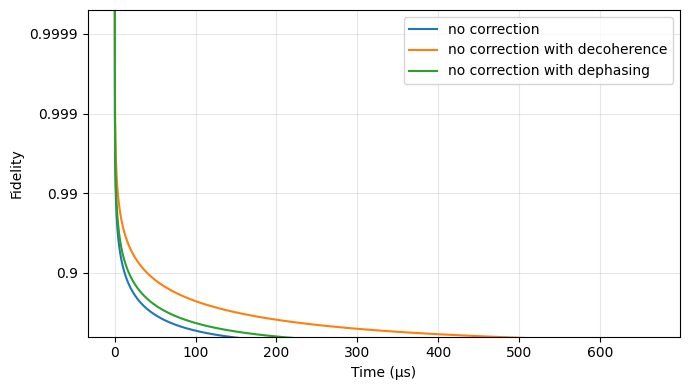

In [ ]:


from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup


T1 = 280
T2 = 100
trotterer_4 = runner.generate_trotterizer(single_qubit_time, T1, T2, 2, 4)

amp_damp = AmplitudeDamping(T1=T1, hilbert_space_dim=2, num_qubits=4)
phase_damping = PhaseDamping(T1=T1, T2=T2, hilbert_space_dim=2, num_qubits=4)
trotterizer_phase = TrotterGroup([phase_damping], 0.03)
trotterizer_decoherence = TrotterGroup([amp_damp], 0.03)

no_correction_decoherence = runner.run_unitary_circuit(trotterizer_decoherence, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   
no_correction_phase= runner.run_unitary_circuit(trotterizer_phase, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   
no_correction = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   


time_steps_4 = np.linspace(0, 0.03 * len(no_correction), len(no_correction))


plus_state = qt.gates.snot() * qt.basis(2, 0)
init_rho = qt.ket2dm(qt.tensor(plus_state, plus_state, plus_state))

# qt.fidelity returns sqrt-fidelity
def infid(states):
    F = np.array([qt.fidelity(s.ptrace([0, 1, 2]), init_rho) for s in states])**2
    return 1 - F

infid_nc = infid(no_correction)
infid_ncd = infid(no_correction_decoherence)
infid_ncp = infid(no_correction_phase)

# Guard against exactly-1 fidelity producing zero infidelity
floor = 1e-12

infid_nc = np.clip(infid_nc, floor, None)
infid_ncd = np.clip(infid_ncd, floor, None)
infid_ncp = np.clip(infid_ncp, floor, None)

from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(time_steps_4, infid_nc, label='no correction')
ax.plot(time_steps_4, infid_ncd, label='no correction with decoherence')
ax.plot(time_steps_4, infid_ncp, label='no correction with dephasing')

ax.set_yscale('log')

nines = range(1, 5)
tick_positions = [10.0 ** (-k) for k in nines]
tick_labels = ['0.' + '9' * k for k in nines]

ax.set_ylim(10 ** (-(max(nines) + 0.3)), 10 ** (-(min(nines) - 0.8)))
ax.yaxis.set_major_locator(FixedLocator(tick_positions))
ax.yaxis.set_major_formatter(FixedFormatter(tick_labels))
ax.yaxis.set_minor_locator(NullLocator())
ax.invert_yaxis()
ax.set_ylabel('Fidelity')
ax.set_xlabel('Time (μs)')
ax.legend()
ax.grid(True, which='major', alpha=0.3)

#ax.set_title(f"Fidelity between |+++> Over Time with T1 = {t1:.1f}μs, T2 = {t2:.1f}μs")
plt.tight_layout()
#plt.savefig(os.path.join(output_path, 'fidelities_plot.png'), dpi=150)
plt.show()


plt.plot(time_steps_4, infid_nc, label="no correction")



/home/wrn13/Research/QuantumLogicalSimulator/.venv/lib/python3.11/site-packages/qutip/core/data/expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


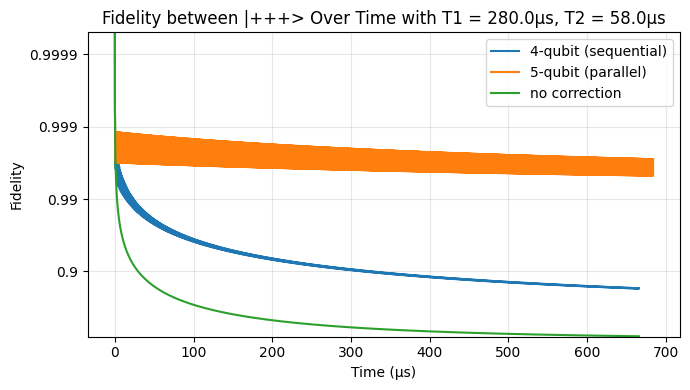

In [24]:
T1 = 280
T2 = 58


from quantum_logical.qubit_phase import qubit_parallel_phase_circuit, qubit_partial_phase_circuit


single_qubit_time = 0.03 # 30 nanosec
two_qubit_time = 0.102 # 102 nanosec

plus_state = qt.gates.snot() * qt.basis(2,0)
init_state = qt.tensor(plus_state, plus_state, plus_state)

init_rho = qt.ket2dm(init_state)


n = 600

setup_5 = [
qubit_parallel_phase_circuit(single_qubit_time, two_qubit_time, num_ancillae=2)
] * 2*n

setup_4 = [
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 0),
qubit_partial_phase_circuit(single_qubit_time, two_qubit_time, target_state = 1),
] * n

ancilla_zero = qt.ket2dm(qt.basis(2, 0))
state_list_4 = runner.experiment_partial_run(trotterer_4, qt.tensor(init_rho, ancilla_zero), setup_4)
state_list_5 = runner.experiment_partial_run(trotterer_5, qt.tensor(init_rho, ancilla_zero, ancilla_zero), setup_5)

ideal_dropped_states_4 = [qt.tensor(init_rho, ancilla_zero)]
ideal_dropped_states_5 = [qt.tensor(init_rho, ancilla_zero, ancilla_zero)]
ideal_dropped_states_4 = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[0], [37 * single_qubit_time])[:-1]
ideal_dropped_states_5 = runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[0], [19 * single_qubit_time])[:-1]
ideal_dropped_states_4.append(state_list_4[37])
ideal_dropped_states_5.append(state_list_5[19])
for i in range(1,n):
    ideal_dropped_states_4 += runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], state_list_4[37 * i], [37 * single_qubit_time])[1:-1]
    ideal_dropped_states_4.append(state_list_4[37*(i+1)])
for i in range(1,2*n):
    ideal_dropped_states_5 += runner.run_unitary_circuit(trotterer_5, [qt.tensor(*[qt.qeye(2)]*5)], state_list_5[19 * i], [19 * single_qubit_time])[1:-1]
    ideal_dropped_states_5.append(state_list_5[19*(i+1)])
    
no_correction = runner.run_unitary_circuit(trotterer_4, [qt.tensor(*[qt.qeye(2)]*4)], qt.tensor(init_rho, ancilla_zero), [len(ideal_dropped_states_4) * single_qubit_time]) [:-1]   

ideal_plot_results_log_plot(0.03, ideal_dropped_states_4, ideal_dropped_states_5, no_correction, f"results/T1_{T1}_T2_{T2}/ideals", T1, T2)
